# Лабораторная — Часть 2: Baseline
## YOLOv11n (CNN) + YOLOv11l (Attention-based)

| Модель | Тип | Backbone | Параметры |
|---|---|---|---|
| YOLOv11n | CNN | CSPNet + C3k2 | 2.6M |
| YOLOv11l | Attention | CSPNet + C2PSA (Self-Attention) | 25M |

> RT-DETR-L не сошёлся на датасете ~300 изображений — трансформерам требуется значительно больше данных. YOLOv11l содержит C2PSA блоки с механизмом self-attention и является архитектурно близкой альтернативой.

In [2]:
import os, glob, time
import numpy as np
from pathlib import Path
import torch
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
%matplotlib inline
print(f'PyTorch: {torch.__version__}')
print(f'CUDA:    {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:     {torch.cuda.get_device_name(0)}')

DATA_YAML = str(Path('data.yaml').absolute())
DEVICE    = 0
EPOCHS    = 30
IMGSZ     = 640
WORKERS   = 0

assert os.path.exists(DATA_YAML), 'data.yaml не найден!'

val_imgs = (glob.glob('valid/images/*.jpg') +
            glob.glob('valid/images/*.png'))[:10]
print(f'\ndata.yaml: {DATA_YAML}')
print(f'Val imgs:  {len(val_imgs)}')

PyTorch: 2.5.1+cu121
CUDA:    True
GPU:     NVIDIA GeForce RTX 3060 Ti

data.yaml: C:\Users\meteo\Desktop\cyber-physical-systems\lr11\data.yaml
Val imgs:  10


## 1. YOLOv11n — CNN baseline

In [3]:
print('Обучение YOLOv11n (CNN)...')
YOLO('yolo11n.pt').train(
    data=DATA_YAML, epochs=EPOCHS, imgsz=IMGSZ, batch=16,
    device=DEVICE, project='runs/baseline', name='yolo11n',
    pretrained=True, exist_ok=True, workers=WORKERS,
    optimizer='SGD', lr0=0.01, lrf=0.01,
    momentum=0.937, weight_decay=0.0005, warmup_epochs=3,
    mosaic=1.0, mixup=0.0, degrees=0.0,
    translate=0.1, scale=0.5, fliplr=0.5,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
)
print('YOLOv11n готова!')

Обучение YOLOv11n (CNN)...
New https://pypi.org/project/ultralytics/8.4.34 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine\trainer: task=detect, mode=train, model=yolo11n.pt, data=C:\Users\meteo\Desktop\cyber-physical-systems\lr11\data.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=0, project=runs/baseline, name=yolo11n, exist_ok=True, pretrained=True, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_n

train: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\labels.cache... 606 images, 0 backgrounds, 0 corrupt: 100%|██████████| 606/606 [00:00<?, ?it/s]

train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.0fe973299ff9e73874d9e684cba4e406.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.5e1a9d49ad09f5a7549225a05e1f66a6.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.bb226be189ee3a6399fbbd5080852e5b.jpg: 1 duplicate labels removed
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))



val: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\valid\labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]


Plotting labels to runs\baseline\yolo11n\labels.jpg... 
optimizer: SGD(lr=0.01, momentum=0.937) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to runs\baseline\yolo11n
Starting training for 30 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      30/30      2.49G     0.8425     0.5769     0.9962        152        640: 100%|██████████| 38/38 [00:10<00:00,  3.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  4.01it/s]

                   all         58        386      0.981      0.986      0.986       0.79



30 epochs completed in 0.109 hours.
Optimizer stripped from runs\baseline\yolo11n\weights\last.pt, 5.5MB
Optimizer stripped from runs\baseline\yolo11n\weights\best.pt, 5.5MB

Validating runs\baseline\yolo11n\weights\best.pt...
Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLO11n summary (fused): 238 layers, 2,584,687 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.16it/s]


                   all         58        386      0.981      0.986      0.986      0.792
          black-bishop         13         22      0.996      0.955      0.956      0.707
            black-king         29         29          1      0.946      0.992      0.824
          black-knight         26         30          1       0.99      0.995       0.79
            black-pawn         25         77      0.998          1      0.995      0.782
           black-queen         11         11      0.901          1      0.988      0.811
            black-rook         24         28          1      0.982      0.995      0.784
          white-bishop         17         22      0.953          1       0.96      0.785
            white-king         29         29      0.993          1      0.995      0.849
          white-knight         17         19      0.946          1      0.995      0.815
            white-pawn         26         77      0.998          1      0.995      0.784
           white-quee

In [4]:
model_cnn_best = YOLO('runs/baseline/yolo11n/weights/best.pt')
m = model_cnn_best.val(data=DATA_YAML, device=DEVICE, workers=WORKERS)

map50_cnn   = float(m.box.map50)
map5095_cnn = float(m.box.map)
p_cnn = float(np.mean(m.box.p)) if m.box.p is not None and len(m.box.p) > 0 else 0.0
r_cnn = float(np.mean(m.box.r)) if m.box.r is not None and len(m.box.r) > 0 else 0.0

t0 = time.time()
if val_imgs:
    model_cnn_best.predict(val_imgs, device=DEVICE, verbose=False)
speed_cnn = (time.time()-t0) / max(len(val_imgs),1) * 1000

print(f"""
=== YOLOv11n (CNN) ===
mAP@50      : {map50_cnn:.4f}
mAP@50-95   : {map5095_cnn:.4f}
Precision   : {p_cnn:.4f}
Recall      : {r_cnn:.4f}
Inference   : {speed_cnn:.1f} мс""")

Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLO11n summary (fused): 238 layers, 2,584,687 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\valid\labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:01<00:00,  3.13it/s]


                   all         58        386      0.981      0.986      0.986       0.79
          black-bishop         13         22      0.996      0.955      0.956       0.71
            black-king         29         29          1      0.946      0.992       0.83
          black-knight         26         30          1       0.99      0.995       0.79
            black-pawn         25         77      0.998          1      0.995      0.783
           black-queen         11         11      0.901          1      0.988      0.795
            black-rook         24         28          1      0.982      0.995      0.783
          white-bishop         17         22      0.953          1       0.96      0.771
            white-king         29         29      0.993          1      0.995      0.839
          white-knight         17         19      0.946          1      0.995      0.821
            white-pawn         26         77      0.998          1      0.995       0.78
           white-quee

## 2. YOLOv11l — Attention-based baseline

In [5]:
print('Обучение YOLOv11l (Attention-based)...')
YOLO('yolo11l.pt').train(
    data=DATA_YAML, epochs=EPOCHS, imgsz=IMGSZ, batch=8,
    device=DEVICE, project='runs/baseline', name='yolo11l',
    pretrained=True, exist_ok=True, workers=WORKERS,
    optimizer='AdamW', lr0=0.001, lrf=0.001,
    weight_decay=0.0005, warmup_epochs=3,
    mosaic=1.0, mixup=0.0, degrees=0.0,
    translate=0.1, scale=0.5, fliplr=0.5,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
)
print('YOLOv11l готова!')

Обучение YOLOv11l (Attention-based)...


KeyboardInterrupt: 

In [6]:
model_rt_best = YOLO('runs/baseline/yolo11l/weights/best.pt')
m = model_rt_best.val(data=DATA_YAML, device=DEVICE, workers=WORKERS)

map50_rt   = float(m.box.map50)
map5095_rt = float(m.box.map)
p_rt = float(np.mean(m.box.p)) if m.box.p is not None and len(m.box.p) > 0 else 0.0
r_rt = float(np.mean(m.box.r)) if m.box.r is not None and len(m.box.r) > 0 else 0.0

t0 = time.time()
if val_imgs:
    model_rt_best.predict(val_imgs, device=DEVICE, verbose=False)
speed_rt = (time.time()-t0) / max(len(val_imgs),1) * 1000

print(f"""
=== YOLOv11l (Attention) ===
mAP@50      : {map50_rt:.4f}
mAP@50-95   : {map5095_rt:.4f}
Precision   : {p_rt:.4f}
Recall      : {r_rt:.4f}
Inference   : {speed_rt:.1f} мс""")

Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLO11l summary (fused): 464 layers, 25,289,335 parameters, 0 gradients, 86.6 GFLOPs


val: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\valid\labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:01<00:00,  2.16it/s]


                   all         58        386      0.982      0.993      0.986      0.801
          black-bishop         13         22          1      0.955      0.961      0.707
            black-king         29         29          1      0.997      0.995      0.854
          black-knight         26         30      0.992          1      0.995      0.815
            black-pawn         25         77      0.997          1      0.995      0.817
           black-queen         11         11      0.956          1      0.995        0.8
            black-rook         24         28       0.99          1      0.995      0.795
          white-bishop         17         22      0.944          1      0.968      0.815
            white-king         29         29      0.991          1      0.995      0.814
          white-knight         17         19      0.943          1      0.959        0.8
            white-pawn         26         77      0.997          1      0.995      0.801
           white-quee

## Сравнение и графики

In [7]:
df = pd.DataFrame([
    {'Модель': 'YOLOv11n (CNN)',
     'Тип': 'CNN', 'Параметры': '2.6M',
     'mAP@50': round(map50_cnn,4), 'mAP@50-95': round(map5095_cnn,4),
     'Precision': round(p_cnn,4),  'Recall': round(r_cnn,4),
     'Inference(ms)': round(speed_cnn,1)},
    {'Модель': 'YOLOv11l (Attention)',
     'Тип': 'Attention (C2PSA)', 'Параметры': '25M',
     'mAP@50': round(map50_rt,4), 'mAP@50-95': round(map5095_rt,4),
     'Precision': round(p_rt,4),  'Recall': round(r_rt,4),
     'Inference(ms)': round(speed_rt,1)},
])
print('=== BASELINE РЕЗУЛЬТАТЫ ===')
print(df.to_string(index=False))
df.to_csv('baseline_results.csv', index=False)
print('\nСохранено: baseline_results.csv')

=== BASELINE РЕЗУЛЬТАТЫ ===
              Модель               Тип Параметры  mAP@50  mAP@50-95  Precision  Recall  Inference(ms)
      YOLOv11n (CNN)               CNN      2.6M  0.9860     0.7902     0.9806  0.9861           12.0
YOLOv11l (Attention) Attention (C2PSA)       25M  0.9856     0.8014     0.9822  0.9927           18.0

Сохранено: baseline_results.csv


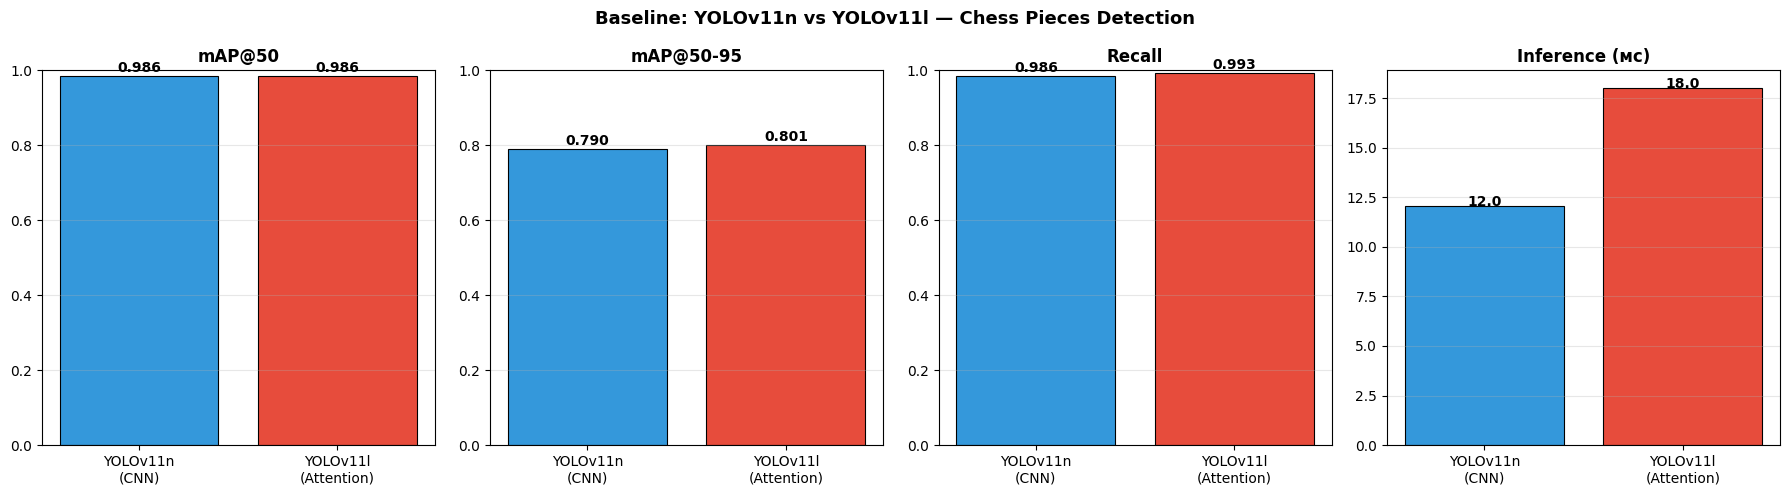

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Baseline: YOLOv11n vs YOLOv11l — Chess Pieces Detection',
             fontsize=13, fontweight='bold')
models  = ['YOLOv11n\n(CNN)', 'YOLOv11l\n(Attention)']
palette = ['#3498DB', '#E74C3C']

for ax, (title, vals) in zip(axes, [
    ('mAP@50',         [map50_cnn,   map50_rt]),
    ('mAP@50-95',      [map5095_cnn, map5095_rt]),
    ('Recall',         [r_cnn,       r_rt]),
    ('Inference (мс)', [speed_cnn,   speed_rt]),
]):
    bars = ax.bar(models, vals, color=palette, edgecolor='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    if title != 'Inference (мс)':
        ax.set_ylim(0, 1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{v:.3f}' if title != 'Inference (мс)' else f'{v:.1f}',
                ha='center', fontweight='bold', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

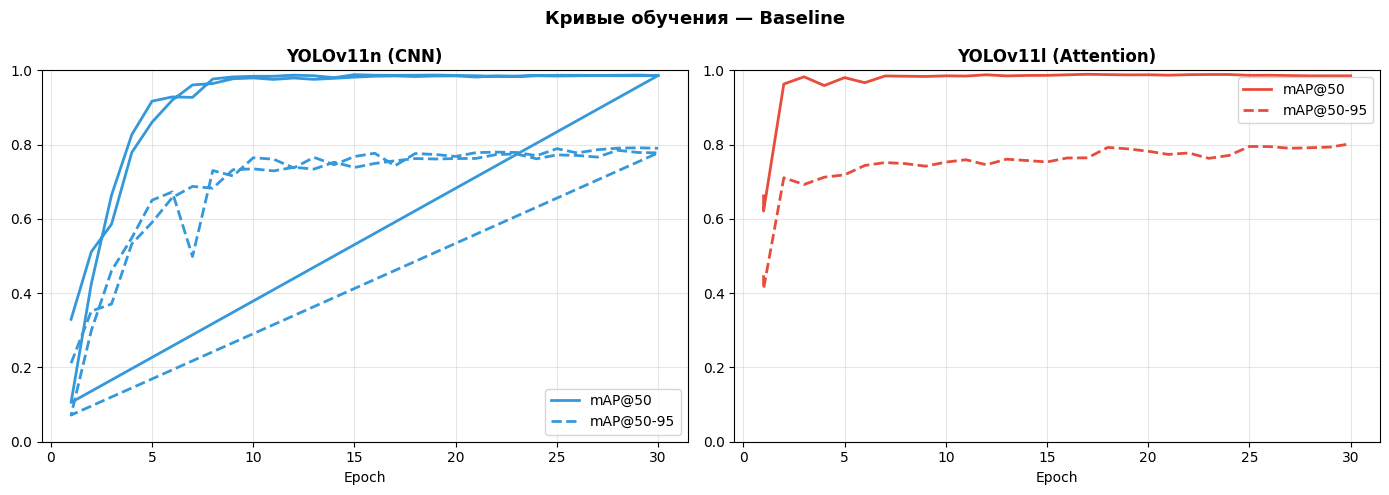

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Кривые обучения — Baseline', fontsize=13, fontweight='bold')

for ax, (name, csv_path, color) in zip(axes, [
    ('YOLOv11n (CNN)',       'runs/baseline/yolo11n/results.csv', '#3498DB'),
    ('YOLOv11l (Attention)', 'runs/baseline/yolo11l/results.csv', '#E74C3C'),
]):
    if not os.path.exists(csv_path):
        ax.text(0.5, 0.5, 'results.csv не найден',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name)
        continue
    df_r = pd.read_csv(csv_path)
    df_r.columns = df_r.columns.str.strip()
    for col, ls, lbl in [
        ('metrics/mAP50(B)',    '-',  'mAP@50'),
        ('metrics/mAP50-95(B)', '--', 'mAP@50-95'),
    ]:
        if col in df_r.columns:
            ax.plot(df_r['epoch'], df_r[col],
                    color=color, linestyle=ls, linewidth=2, label=lbl)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

['valid/images\\05ad7223827a29a8283f6c4b2490f52f_jpg.rf.7c134acea5ef5e18aa75defc069dc1ee.jpg', 'valid/images\\0b2252c93c53e1b2e61d485b22328e2e_jpg.rf.0a885b88adc72caa71b0aa0ec20b863e.jpg', 'valid/images\\0c09b79cff39932c59ecc745dd827906_jpg.rf.dd62f1f1d28dd2209e0cfe61288f6438.jpg', 'valid/images\\0d9afc3d23392c3958f53d7fe71fd2f1_jpg.rf.ca639b6fd216ff59ed8fd5572c13985f.jpg', 'valid/images\\15cc23c777b00d0e123f9df468f2852b_jpg.rf.ec883ea8696547433314cdd8f2c177bf.jpg', 'valid/images\\18742c87a03866e042c5659ba04d1180_jpg.rf.ec846d30e3eebb02abb8056342b9de32.jpg', 'valid/images\\1b7c1c9570e900f75eb974f99cbb3c60_jpg.rf.ec7b31959243b9f7a54b7c3ea89dbce6.jpg', 'valid/images\\1be2a621f309c7482e9a79ad5b23ecbe_jpg.rf.e4117f6396582d8058dbd15974e30b04.jpg', 'valid/images\\26fa37995fa5b18ec40e0a94e6d91104_jpg.rf.2e6b063142cfe7cbcc21b0a236e5699f.jpg', 'valid/images\\302e7c10664be32b4fc000452149027c_jpg.rf.9e3b8da2de02c1fe13ae9b9bf0d28d00.jpg']
10


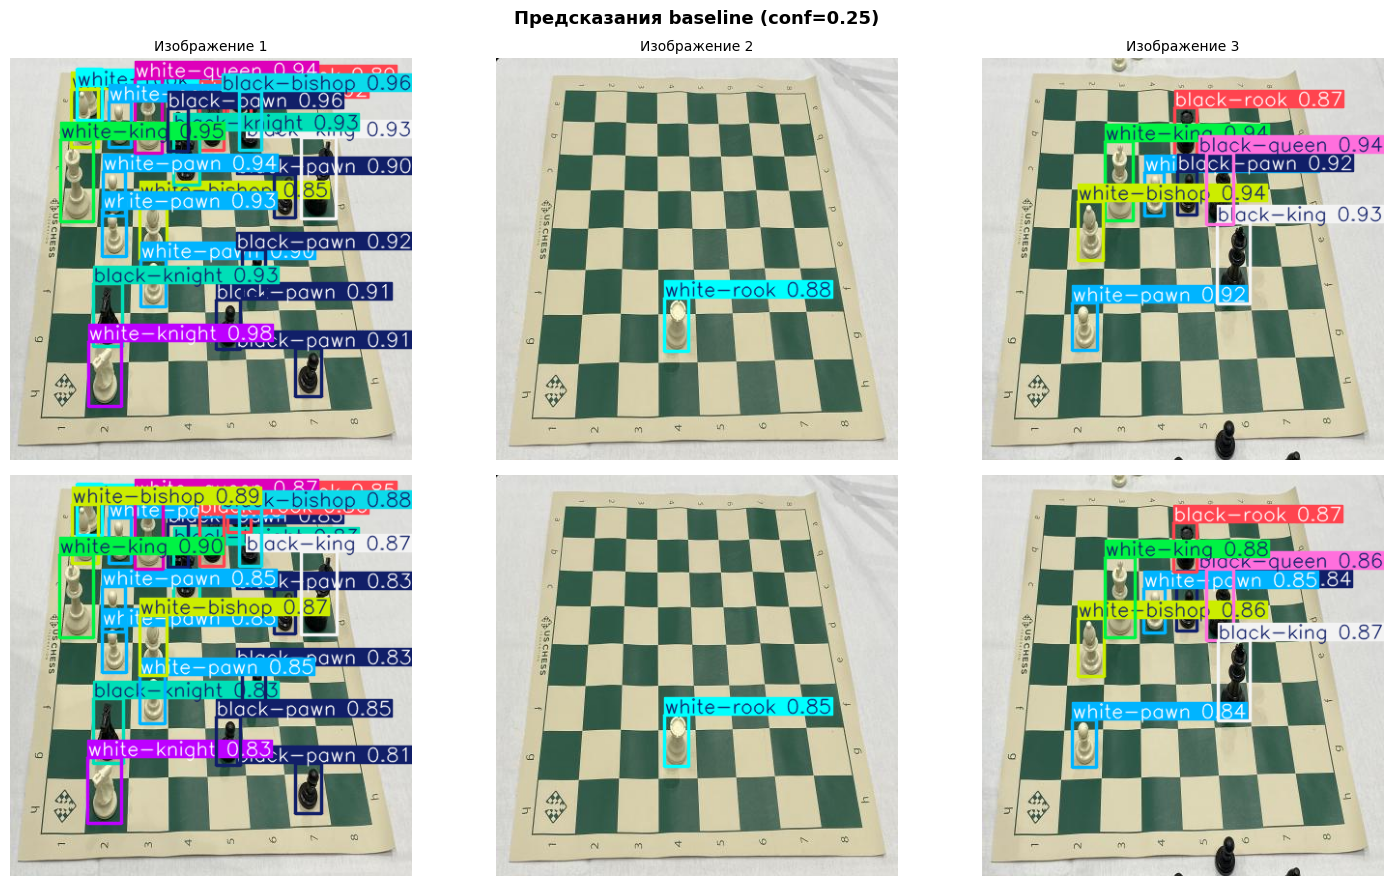

In [10]:
sample_imgs = val_imgs[:3]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Предсказания baseline (conf=0.25)', fontsize=13, fontweight='bold')
print(val_imgs)
print(len(val_imgs))

for col, img_path in enumerate(sample_imgs):
    for row, (model, name) in enumerate([
        (model_cnn_best, 'YOLOv11n (CNN)'),
        (model_rt_best,  'YOLOv11l (Attention)'),
    ]):
        pred = model.predict(img_path, device=DEVICE, verbose=False, conf=0.25)
        axes[row][col].imshow(pred[0].plot()[..., ::-1])
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(name, fontsize=10, fontweight='bold')
        if row == 0:
            axes[row][col].set_title(f'Изображение {col+1}', fontsize=10)

plt.tight_layout()
plt.savefig('predictions_baseline.png', dpi=150, bbox_inches='tight')
plt.show()